In [1]:
import numpy as np
import joblib
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(
    "../data/processed/featured_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392,1.182783,0.198747,149.140825
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367,2.020910,-0.370867,278.526341
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780,1.508423,0.859774,50.182390
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492,1.491866,0.320931,148.400233
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209,1.154459,4.180581,96.843708


In [3]:
# 1. Spatial blocks: cut the city into a 10x10 grid
n_bins = 10
df["lat_bin"] = pd.cut(df["Latitude"], bins=n_bins, labels=False)
df["lon_bin"] = pd.cut(df["Longitude"], bins=n_bins, labels=False)
df["spatial_block"] = df["lat_bin"].astype(str) + "_" + df["lon_bin"].astype(str)

# 2. Physics-only features (no Lat/Long, no engineered duplicates)
FEATURES = ["NDVI", "NDBI", "Elevation", "Population"]
X = df[FEATURES]
y = df["LST"]
groups = df["spatial_block"]

# 3. Spatial cross-validation with out-of-fold predictions
gkf = GroupKFold(n_splits=5)
oof_pred = np.zeros(len(y))

for tr, te in gkf.split(X, y, groups):
    m = RandomForestRegressor(n_estimators=300, random_state=42)
    m.fit(X.iloc[tr], y.iloc[tr])
    oof_pred[te] = m.predict(X.iloc[te])

mae  = mean_absolute_error(y, oof_pred)
rmse = mean_squared_error(y, oof_pred) ** 0.5
r2   = r2_score(y, oof_pred)

print("Random Forest V3 - Spatial CV (honest generalisation)")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")

# 4. Train final model on ALL data, save for later notebooks
final_model = RandomForestRegressor(n_estimators=300, random_state=42)
final_model.fit(X, y)
joblib.dump(final_model, "../outputs/lst_model_v3.pkl")
print("\nSaved -> outputs/lst_model_v3.pkl")

Random Forest V3 - Spatial CV (honest generalisation)
MAE  : 1.793
RMSE : 2.282
R2   : 0.501

Saved -> outputs/lst_model_v3.pkl


In [4]:
comparison = pd.DataFrame({"Actual": y, "Predicted": oof_pred})
comparison.head(10)

,Actual,Predicted
0,43.919170,45.576415
1,39.060455,39.777459
2,40.231127,42.196329
3,44.884761,45.694239
4,48.502735,45.636942
5,36.192736,40.106090
6,46.896266,45.552887
7,38.221331,40.744565
8,39.990156,43.946737
9,47.634558,43.078326


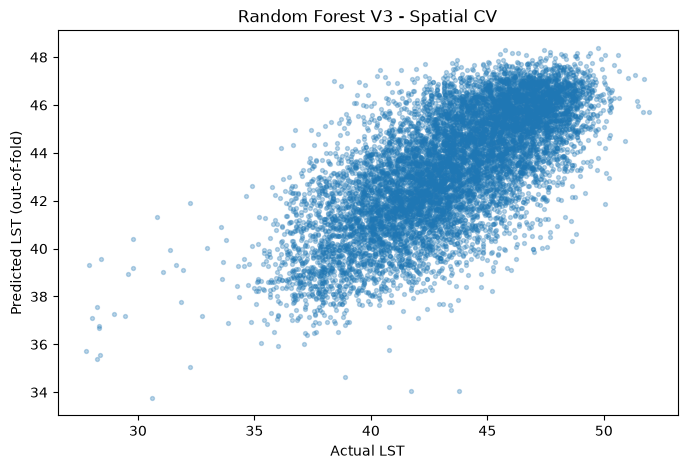

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y, oof_pred, s=8, alpha=0.3)
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST (out-of-fold)")
plt.title("Random Forest V3 - Spatial CV")
plt.show()